In [3]:
import sys, os
sys.path.append(os.path.abspath("../../"))

# Load shared utilities for attention-from-scratch analysis
from scripts.attention_from_scratch_utils import *

# Set reproducible seed
set_seed(42)

print("Environment ready.")
print("Device:", device)

Environment ready.
Device: mps


# 02 — Multi-Head Attention (MHA)

This notebook expands single-head attention into **multi-head attention**, allowing transformers to learn multiple interaction patterns simultaneously.

### What we'll explore
- Why multiple heads are necessary
- Splitting embeddings into heads
- Parallel attention processing
- Concatenation and output projection
- Visualizing multi-head behavior

## Our Simple Embedding Features (8 Dimensions)

To make multi-head attention easier to understand,  
we will create small, interpretable 8-dimensional embeddings.

You can conceptualise each dimension representing a simple, intuitive feature:

| **Feature (Dim)** | **Intuition**                   |
|-------------------|-------------------------------|
| dim1              | Is it an **animal**?          |
| dim2              | Is it an **action** (verb)?   |
| dim3              | Is it a **determiner**?       |
| dim4              | Is it **plural**?             |
| dim5              | **Subject-ness**              |
| dim6              | **Object-ness**               |
| dim7              | **Abstractness**              |
| dim8              | Filler (just to make 8 dims)  |

These are **not real linguistic features** — they are  
**simple teaching tools** so we can easily inspect what each head does.

In a real transformer, these features are *learned automatically*  
and are far more abstract.

## Why Multiple Heads?

A single attention head can only learn **one type** of interaction pattern at a time.

For example, a single head might learn:
- how **verbs** relate to their **subjects**
- how **nouns** relate to their **determiners**
- how tokens should attend to **previous** or **next** tokens

But real language contains **many different relationships happening simultaneously**, such as:
- syntactic structure  
- semantic meaning  
- positional information  
- long-range dependencies  
- short-range dependencies  

A single head cannot capture all of these patterns at once.

---

## How Multi-Head Attention Solves the Problem

Instead of relying on one head to learn every relationship,  
Transformers use **multiple attention heads**, each with its own:

- **Query projection matrix**  
- **Key projection matrix**  
- **Value projection matrix**

Because each head has its own parameters,  
each one can specialize in a *different* pattern.

Examples of different head behaviors:
- One head tracks **subject → verb**  
- Another tracks **verb → object**  
- Another matches **determiner → noun**  
- Another focuses on **positional alignment**  
- Another focuses on **semantic similarity**  

---

## All Heads Run in Parallel

Each head performs attention independently, producing its own output.  
These outputs are then **combined** into a single, richer representation.

This gives the transformer multiple “views” of the sequence,  
allowing it to understand **many aspects** of language at the same time.

In [25]:
import numpy as np
import pandas as pd

tokens = ["The", "cat", "chased", "the", "mouse"]

# Simple, interpretable 8-dimensional toy embeddings (0/1 values)
embeddings = {
    "The":    np.array([0, 0, 1, 0, 1, 0, 0, 0]),
    "cat":    np.array([1, 0, 0, 0, 1, 0, 0, 0]),
    "chased": np.array([0, 1, 0, 0, 0, 0, 0, 0]),
    "the":    np.array([0, 0, 1, 0, 0, 0, 0, 0]),
    "mouse":  np.array([1, 0, 0, 0, 0, 1, 0, 0]),
}

embed_dim = 8

# Build a DataFrame with nice column names: dim_1, dim_2, ..., dim_8
df_embeddings = pd.DataFrame(
    [embeddings[tok] for tok in tokens],
    index=tokens,
    columns=[f"dim_{i+1}" for i in range(embed_dim)]
)

print("Embedding dimension:", embed_dim)
df_embeddings

Embedding dimension: 8


,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8
The,0,0,1,0,1,0,0,0
cat,1,0,0,0,1,0,0,0
chased,0,1,0,0,0,0,0,0
the,0,0,1,0,0,0,0,0
mouse,1,0,0,0,0,1,0,0


## Splitting Embeddings Into Multiple Heads

Multi-head attention works by dividing the full embedding into **smaller chunks**, called *heads*.

Example:
- Total dimensions in embedding: **8**  
- Number of heads: **2**  
- Dimensions per head: **4**

The split is **not learned** or intelligent — it is simply an even slicing of the embedding:

| **Component** | **Values**                     |
|---------------|--------------------------------|
| Embedding     | e₁, e₂, e₃, e₄, e₅, e₆, e₇, e₈ |
| Head 1 slice  | e₁, e₂, e₃, e₄                 |
| Head 2 slice  | e₅, e₆, e₇, e₈                 |

Each head receives its own slice and computes attention **independently**,  
allowing different heads to specialise in different relationships.

In this notebook:
- We use small embeddings for clarity  
- We create heads by reshaping the embedding into `(num_heads, head_dim)`

In [35]:
import numpy as np
import pandas as pd
from IPython.display import display, HTML

num_heads = 2
head_dim = embed_dim // num_heads   # 4 dims per head

def split_into_heads(x):
    return x.reshape(num_heads, head_dim)

# Containers for each head’s rows
rows_head1 = []
rows_head2 = []

for tok in tokens:
    heads = split_into_heads(embeddings[tok])
    rows_head1.append([tok, *heads[0]])
    rows_head2.append([tok, *heads[1]])

# Build DataFrames
df_head1 = pd.DataFrame(
    rows_head1,
    columns=["token"] + [f"dim_{i+1}" for i in range(head_dim)]
).set_index("token")

df_head2 = pd.DataFrame(
    rows_head2,
    columns=["token"] + [f"dim_{i+head_dim+1}" for i in range(head_dim)]
).set_index("token")

# Display side by side
display(
    HTML(
        f"""
        <div style="display: flex; gap: 40px;">
            <div>
                <h3>Head 1 (Dims 1–4)</h3>
                {df_head1.to_html()}
            </div>
            <div>
                <h3>Head 2 (Dims 5–8)</h3>
                {df_head2.to_html()}
            </div>
        </div>
        """
    )
)

,dim_1,dim_2,dim_3,dim_4
token,,,,
The,0,0,1,0
cat,1,0,0,0
chased,0,1,0,0
the,0,0,1,0
mouse,1,0,0,0
,dim_5,dim_6,dim_7,dim_8
token,,,,
The,1,0,0,0
cat,1,0,0,0


## Step 3 — Q, K, and V Projections for Each Head

In single-head attention, each token produces **one** Query (Q), Key (K), and Value (V) vector.

In **multi-head attention**, we want the model to look at the sequence in **multiple different ways at once**.  
To achieve this, each head gets its own learned projection matrices:

- one $W_Q^{(h)}$ per head  
- one $W_K^{(h)}$ per head  
- one $W_V^{(h)}$ per head  

Each of these transforms the head’s slice of the embedding into:

- a Query vector  
- a Key vector  
- a Value vector  

---

## Understanding Projection in Multi-Head Attention

When a transformer creates Q, K, and V vectors, it performs a step called **projection**.  
This sounds complicated, but the idea is simple:

> **Projection = applying a learned transformation that gives each head its own “view” of a token.**

---

### Why projection is needed

All heads start with the **same embedding**, but we want them to learn **different patterns**, such as:

- syntax (subject → verb)  
- semantics (similar meaning)  
- long-range dependencies  
- positional structure  

If all heads used the same representation, they would behave identically.  
Projection gives each head its own unique representation.

---

### How projection works

After splitting an embedding into head slices (e.g., 8 dims → 2 heads → 4 dims each):

- Head 1 gets: `[e₁, e₂, e₃, e₄]`  
- Head 2 gets: `[e₅, e₆, e₇, e₈]`  

Each head then applies **three different learned matrices**:

- $W_Q^{(h)}$ to create a Query  
- $W_K^{(h)}$ to create a Key  
- $W_V^{(h)}$ to create a Value  

Each matrix is size `(head_dim × head_dim)`.

The math is:

- $q_h = x_h W_Q^{(h)}$  
- $k_h = x_h W_K^{(h)}$  
- $v_h = x_h W_V^{(h)}$  

This turns the slice \( x_h \) into a new 4-dimensional vector:
- one version for Queries  
- one for Keys  
- one for Values  

Each head learns **its own** transformations.

---

### Intuition (no math)

Think of projection like applying different filters to the same image:

- Filter A highlights edges  
- Filter B boosts colors  
- Filter C blurs the image  

It’s still the same picture, but each filter creates a different interpretation.

Projection does the same with embeddings:
- Head 1 might amplify syntactic features  
- Head 2 might extract semantic meaning  
- Head 3 (if present) might detect long-range relations  

---

## Summary

- An embedding is split into head-sized slices.  
- Each head applies **its own learned matrices** ($W_Q$, $W_K$, $W_V$).  
- These matrices create different Q/K/V vectors for each head.  
- This gives each head a unique “perspective” on the same token.  

Projection is what enables multi-head attention to look at language in **multiple ways simultaneously**.

---

## Visual Diagram — Embedding → Split → Projection

```text
                    ┌───────────────────────────┐
                    │      Token Embedding      │
                    │     (8-dimensional x)     │
                    └─────────────┬─────────────┘
                                  │
                     Split into heads (reshape)
                                  │
        ┌───────────────────────────────────────────────────┐
        │                                                   │
┌───────────────┐                                   ┌───────────────┐
│   Head 1       │                                   │   Head 2       │
│  dims 1–4      │                                   │  dims 5–8      │
│   x₁ = x[0:4]  │                                   │   x₂ = x[4:8]  │
└───────┬────────┘                                   └────────┬───────┘
        │                                                     │
        │        Each head has its own learned matrices       │
        │                                                     │
        ▼                                                     ▼
┌────────────────┐                                 ┌────────────────┐
│   W_Q(Head 1)  │                                 │  W_Q(Head 2)   │
│   W_K(Head 1)  │                                 │  W_K(Head 2)   │
│   W_V(Head 1)  │                                 │  W_V(Head 2)   │
└───────┬────────┘                                 └────────┬───────┘
        │                                                     │
        ▼                                                     ▼
┌────────────────┐                                 ┌────────────────┐
│   Q₁ = x₁ W_Q¹  │                                 │  Q₂ = x₂ W_Q²   │
│   K₁ = x₁ W_K¹  │                                 │  K₂ = x₂ W_K²   │
│   V₁ = x₁ W_V¹  │                                 │  V₂ = x₂ W_V²   │
└────────────────┘                                 └────────────────┘
        │                                                     │
        ▼                                                     ▼
   Head 1 Q/K/V vectors                                 Head 2 Q/K/V vectors
           (4 dims each)                                      (4 dims each)

In [36]:
import numpy as np
import pandas as pd
from IPython.display import display, HTML

num_heads = 2
head_dim = embed_dim // num_heads

def split_into_heads(x):
    return x.reshape(num_heads, head_dim)

def make_df(vec, head, dims):
    return pd.DataFrame(
        [vec],
        index=[head],
        columns=[f"dim_{d}" for d in dims]
    )

def style(df, cmap, title):
    return (
        df.style.background_gradient(cmap=cmap)
        .set_caption(title)
        .set_table_attributes(
            'style="display:inline-block; margin:10px; vertical-align:top; min-width:150px;"'
        )
    )

print("### Q / K / V Projections Per Token (2×3 Grid Layout, No Scroll) ###")

for tok in tokens:
    print(f"\n## Token: {tok} ##\n")

    # Split into heads
    xh = split_into_heads(embeddings[tok])

    # Q/K/V for both heads
    Q1, Q2 = xh[0] @ W_Q[0], xh[1] @ W_Q[1]
    K1, K2 = xh[0] @ W_K[0], xh[1] @ W_K[1]
    V1, V2 = xh[0] @ W_V[0], xh[1] @ W_V[1]

    # DataFrames for Head 1
    df_Q1 = make_df(Q1, "Head 1", [1,2,3,4])
    df_K1 = make_df(K1, "Head 1", [1,2,3,4])
    df_V1 = make_df(V1, "Head 1", [1,2,3,4])

    # DataFrames for Head 2
    df_Q2 = make_df(Q2, "Head 2", [5,6,7,8])
    df_K2 = make_df(K2, "Head 2", [5,6,7,8])
    df_V2 = make_df(V2, "Head 2", [5,6,7,8])

    # Render 2×3 grid (scroll-free)
    html = f"""
    <div style="display:flex; flex-direction:column; gap:5px;">
        <div style="display:flex; gap:20px;">
            {style(df_Q1, "Blues", "Q (Head 1)").to_html()}
            {style(df_K1, "Greens", "K (Head 1)").to_html()}
            {style(df_V1, "Reds", "V (Head 1)").to_html()}
        </div>
        <div style="display:flex; gap:20px;">
            {style(df_Q2, "Blues", "Q (Head 2)").to_html()}
            {style(df_K2, "Greens", "K (Head 2)").to_html()}
            {style(df_V2, "Reds", "V (Head 2)").to_html()}
        </div>
    </div>
    """

    display(HTML(html))

### Q / K / V Projections Per Token (2×3 Grid Layout, No Scroll) ###

## Token: The ##



,dim_1,dim_2,dim_3,dim_4
Head 1,-0.107030,-1.035242,-0.553649,-1.197878
,dim_1,dim_2,dim_3,dim_4
Head 1,1.687142,0.881640,-0.007973,1.479944
,dim_1,dim_2,dim_3,dim_4
Head 1,-1.669405,0.543360,-0.662624,0.570599
,dim_5,dim_6,dim_7,dim_8
Head 2,-0.112328,-0.220970,0.614167,0.757508
,dim_5,dim_6,dim_7,dim_8
Head 2,-1.037246,-0.190339,-0.875618,-1.382800
,dim_5,dim_6,dim_7,dim_8



## Token: cat ##



,dim_1,dim_2,dim_3,dim_4
Head 1,-0.513867,-1.059214,-0.062679,0.955142
,dim_1,dim_2,dim_3,dim_4
Head 1,-0.127918,-0.955540,-1.606446,0.203464
,dim_1,dim_2,dim_3,dim_4
Head 1,-0.238948,-0.907564,-0.576771,0.755391
,dim_5,dim_6,dim_7,dim_8
Head 2,-0.112328,-0.220970,0.614167,0.757508
,dim_5,dim_6,dim_7,dim_8
Head 2,-1.037246,-0.190339,-0.875618,-1.382800
,dim_5,dim_6,dim_7,dim_8



## Token: chased ##



,dim_1,dim_2,dim_3,dim_4
Head 1,-0.985726,0.504047,-0.530258,-0.792873
,dim_1,dim_2,dim_3,dim_4
Head 1,-0.756351,-1.422254,-0.646573,-1.081548
,dim_1,dim_2,dim_3,dim_4
Head 1,0.500917,-0.977555,0.099332,0.751387
,dim_5,dim_6,dim_7,dim_8
Head 2,0.000000,0.000000,0.000000,0.000000
,dim_5,dim_6,dim_7,dim_8
Head 2,0.000000,0.000000,0.000000,0.000000
,dim_5,dim_6,dim_7,dim_8



## Token: the ##



,dim_1,dim_2,dim_3,dim_4
Head 1,-0.107030,-1.035242,-0.553649,-1.197878
,dim_1,dim_2,dim_3,dim_4
Head 1,1.687142,0.881640,-0.007973,1.479944
,dim_1,dim_2,dim_3,dim_4
Head 1,-1.669405,0.543360,-0.662624,0.570599
,dim_5,dim_6,dim_7,dim_8
Head 2,0.000000,0.000000,0.000000,0.000000
,dim_5,dim_6,dim_7,dim_8
Head 2,0.000000,0.000000,0.000000,0.000000
,dim_5,dim_6,dim_7,dim_8



## Token: mouse ##



,dim_1,dim_2,dim_3,dim_4
Head 1,-0.513867,-1.059214,-0.062679,0.955142
,dim_1,dim_2,dim_3,dim_4
Head 1,-0.127918,-0.955540,-1.606446,0.203464
,dim_1,dim_2,dim_3,dim_4
Head 1,-0.238948,-0.907564,-0.576771,0.755391
,dim_5,dim_6,dim_7,dim_8
Head 2,-0.530501,-0.575818,-0.275052,-2.301921
,dim_5,dim_6,dim_7,dim_8
Head 2,0.926178,1.909417,-1.398568,0.562969
,dim_5,dim_6,dim_7,dim_8


## Step 4 — Compute Attention Separately for Each Head

Now that we have per-head Q, K, and V vectors, we can run the full attention computation **independently inside each head**. The math is exactly the same as in Notebook 01, but now applied per head:

1. **Dot product** — measure similarity  
   - $ \text{scores}_{i,j} = q_i \cdot k_j $

2. **Scale** the scores  
   - $ \text{scores} = \frac{\text{scores}}{\sqrt{d_h}} $

3. **Softmax** each row  
   - converts scores into a probability distribution  
   - each row sums to 1  

4. **Weighted sum of V**  
   - $ \text{output}_i = \sum_j \text{weights}_{i,j} \cdot v_j $

This produces one attention output per head.

### Why compute attention *per head*?

Each head sees a **different linear projection** of the embeddings, and therefore learns a **different pattern** in the sequence. For example:
- one head may focus on local context  
- another may track grammatical structure  
- another may follow long-range dependencies  
- another may capture semantic similarity  

Each head outputs a matrix of shape `(num_tokens, head_dim)`. In the next step, we will **concatenate** the outputs from all heads to form a single enriched representation for each token.

### Intuition Recap

Each head runs attention on its own transformed version of the tokens:

- Head 1 sees one “view” of the sentence  
- Head 2 sees another  
- Head 3 (if present) sees another  

Even though the input sentence is the same, the **projection matrices** give each head a unique perspective.

Running attention independently per head lets the model understand the sequence in **multiple complementary ways at once**.

In [45]:
import pandas as pd
from IPython.display import display, HTML

print("### Attention Output Per Head (Side-by-Side, Correct Dimension Labels) ###\n")

def style_output(df, cmap, title):
    return (
        df.style.background_gradient(cmap=cmap)
        .set_caption(title)
        .set_table_attributes(
            'style="display:inline-block; margin:10px; min-width:220px; vertical-align:top;"'
        )
    )

# Build DataFrames for each head
dfs = []

for h in range(num_heads):

    # Correct dimension labels
    if h == 0:
        dim_labels = [f"dim_{i+1}" for i in range(head_dim)]      # dim_1–dim_4
    else:
        dim_labels = [f"dim_{i+1+head_dim}" for i in range(head_dim)]  # dim_5–dim_8

    df = pd.DataFrame(
        attention_output[h],      # (num_tokens, head_dim)
        index=tokens,
        columns=dim_labels
    )

    dfs.append(
        style_output(df, "Purples", f"Head {h+1} (Dims {dim_labels[0]}–{dim_labels[-1]})").to_html()
    )

# Display heads side-by-side
display(HTML(f"""
<div style="display:flex; gap:40px;">
    {''.join(dfs)}
</div>
"""))

### Attention Output Per Head (Side-by-Side, Correct Dimension Labels) ###



,dim_1,dim_2,dim_3,dim_4
The,3.781101,-3.412224,-0.220491,0.883976
cat,3.797309,-3.472982,-0.243491,0.831811
chased,1.741430,-2.050537,-0.502076,0.058767
the,4.141927,-3.649161,-0.201925,1.046802
mouse,1.676005,-2.263398,-0.721982,-0.107046
,dim_5,dim_6,dim_7,dim_8
The,-0.293647,0.176552,-0.625839,-1.220081
cat,0.353004,0.303003,0.016741,-0.919597
chased,0.218598,0.257247,-0.049757,-0.965712
the,0.522139,0.349205,-0.057384,-0.750111


## Step 5 — Concatenate the Outputs from All Heads

Each attention head produces its own output vector for every token.  
These vectors have shape:

- **(num_tokens × head_dim)** per head  
- Example: 5 tokens × 4 dims for each head

However, the transformer does not keep these head outputs separate.  
Instead, it **concatenates** them to form one richer representation per token.

---

### Why Concatenate?

Each head captures a *different kind of relationship* in the sequence:

- Head 1 might capture local context  
- Head 2 might capture syntactic roles  
- Another head might track long-range dependencies  
- Another might focus on semantic similarity  

By placing all head outputs **side by side**, the model gains a combined representation
that includes every pattern learned by every head.

Concatenation simply stacks the head outputs along the feature dimension:

$
\text{Concat}(H_1, H_2, \dots, H_h)
$

---

### What the Concatenated Vector Looks Like

If we have:

- 2 heads  
- 4 dimensions per head  

Then the concatenated output becomes:

$
(4\ \text{dims from Head 1}) \;\|\; (4\ \text{dims from Head 2})
$

giving a final output of **8 dimensions per token**, matching the original embedding size.

---

### Result of This Step

- You now have **one unified embedding per token**
- Its dimensionality = `num_heads × head_dim`
- It contains **all the information** learned by every head
- This prepares the output for the final projection step \( W_O \) in Step 6

This completes the multi-head attention computation *per head*;  
next, we will mix these combined features with one last learned matrix.

In [47]:
import numpy as np
import pandas as pd
from IPython.display import display, HTML

print("### Step 5 — Concatenating Outputs From All Heads ###\n")

# attention_output shape: (num_heads, num_tokens, head_dim)
# Example: (2, 5, 4)

num_tokens = len(tokens)

# --- Concatenate the heads along the last dimension ---
# From: (num_heads, num_tokens, head_dim)
# To:   (num_tokens, num_heads * head_dim)
concat_output = np.concatenate(attention_output, axis=-1)  # (2 heads × 4 dims = 8 dims)
concat_output = concat_output  # now shape: (num_tokens, 8)

# --- Build DataFrame with correct dimension naming ---
dim_labels = [f"dim_{i+1}" for i in range(embed_dim)]  # dim_1 ... dim_8

df_concat = pd.DataFrame(concat_output, index=tokens, columns=dim_labels)

# --- Styling ---
def style_concat(df, title):
    return (
        df.style.background_gradient(cmap="PuBu")
          .set_caption(title)
          .set_table_attributes(
              'style="display:inline-block; margin:10px; min-width:450px; vertical-align:top;"'
          )
    )

display(
    HTML(
        style_concat(df_concat, "Concatenated Output (All Heads Combined)").to_html()
    )
)

### Step 5 — Concatenating Outputs From All Heads ###



,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8
The,3.781101,-3.412224,-0.220491,0.883976,-0.293647,0.176552,-0.625839,-1.220081
cat,3.797309,-3.472982,-0.243491,0.831811,0.353004,0.303003,0.016741,-0.919597
chased,1.741430,-2.050537,-0.502076,0.058767,0.218598,0.257247,-0.049757,-0.965712
the,4.141927,-3.649161,-0.201925,1.046802,0.522139,0.349205,-0.057384,-0.750111
mouse,1.676005,-2.263398,-0.721982,-0.107046,0.270781,0.015280,-1.740948,0.596606


## Step 6 — Final Linear Projection (the Output Matrix $W_O$)

After computing attention **separately for each head** and then **concatenating** the results, we obtain a vector of size equal to the full embedding dimension.

For 2 heads with 4 dimensions each:

- Head 1 output → 4 dims  
- Head 2 output → 4 dims  
- Concatenated output → **8 dims**

This concatenated vector is:

$$
\text{Concat}(H_1, H_2)
$$

But we’re *not* done!  
Transformers always apply a final learned projection matrix called **$W_O$**.

---

### Why do we need the final projection?

Concatenation simply stacks the head outputs.  
The model still needs to:

- mix information **across** heads  
- decide which heads matter more  
- create one unified representation  
- map the concatenated vector back into the model’s embedding space  

This is done using a learned matrix  
$$
W_O \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}
$$

---

### The math

For each token:

$$
\text{final\_output}_i
=
\text{Concat}(H_1, H_2, \dots, H_h)\, W_O
$$

Where:

- each $H_h$ is the attention output of head $h$  
- concatenation produces a vector of size $d_{\text{model}}$  
- the final projection mixes all heads together  

---

### Intuition

Think of this step as blending the different “perspectives” learned by the heads:

- Head 1 might focus on grammatical roles  
- Head 2 might focus on semantic meaning  
- Head 3 (if present) might focus on long-range structure  

The output projection $W_O$ combines these into one enriched vector per token.

---

### Summary

- Multi-head attention produces **many small vectors**, one per head  
- These are **concatenated** into a single large vector  
- The final projection $W_O$ transforms this vector into the final output  
- The output has the **same dimension as the original embedding**

This completes the multi-head attention mechanism before adding the residual connection and feed-forward layers.

In [48]:
import numpy as np
import pandas as pd
from IPython.display import display, HTML

print("### Step 6 — Apply Final Output Projection (W_O) ###\n")

# ---------------------------------------------------------
# 1. Create a learned output projection matrix W_O
# ---------------------------------------------------------
# Shape: (embed_dim, embed_dim) → 8×8 for our example
W_O = np.random.randn(embed_dim, embed_dim)

# ---------------------------------------------------------
# 2. Apply projection:
#    final_output = concat_output @ W_O
# ---------------------------------------------------------
final_output = concat_output @ W_O   # shape: (num_tokens, 8)

# ---------------------------------------------------------
# 3. Build DataFrame with dimension labels
# ---------------------------------------------------------
dim_labels = [f"dim_{i+1}" for i in range(embed_dim)]
df_final = pd.DataFrame(final_output, index=tokens, columns=dim_labels)

# ---------------------------------------------------------
# 4. Styling function for consistency
# ---------------------------------------------------------
def style_final(df, title):
    return (
        df.style.background_gradient(cmap="BuPu")
          .set_caption(title)
          .set_table_attributes(
              'style="display:inline-block; margin:10px; min-width:450px; vertical-align:top;"'
          )
    )

# ---------------------------------------------------------
# 5. Display
# ---------------------------------------------------------
display(
    HTML(
        style_final(df_final, "Final Output After Applying W_O").to_html()
    )
)

### Step 6 — Apply Final Output Projection (W_O) ###



,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8
The,-16.308331,-3.915860,-0.503044,0.370797,2.802974,-2.617936,1.212971,-0.353118
cat,-15.617815,-3.506455,-0.621410,1.024344,3.068633,-3.022415,1.094253,1.084859
chased,-7.610782,-1.865796,-1.456424,-0.499190,0.964056,-2.047562,1.340086,2.525035
the,-16.924437,-3.854388,-0.642675,1.795553,3.588350,-2.937569,1.160316,0.711168
mouse,-7.110271,-4.290758,-2.122744,2.641277,1.644280,2.982996,1.119310,0.864587


# Multi-Head Attention — Full Recap

## Step 0 — Input Token Embeddings
Each token begins as a vector of size \( d_{model} \).  
Example:  
- $d_{\text{model}} = 8$ 
- Tokens: *The, cat, chased, the, mouse*

---

## Step 1 — Split Embeddings Into Heads
With 2 heads:
- Heads: $h = 2$
- Per-head dimension:  
  $d_h = d_{\text{model}} / h = 4$

Split by reshaping:
```
[e₁, e₂, e₃, e₄, e₅, e₆, e₇, e₈]
→
Head 1: [e₁, e₂, e₃, e₄]
Head 2: [e₅, e₆, e₇, e₈]
```

---

## Step 2 — Q/K/V Projection Matrices
Each head has its own learned projections:
- $W_Q^{(h)}$
- $W_K^{(h)}$
- $W_V^{(h)}$

Each is a \( 4 \times 4 \) matrix applied to the head slice.

---

## Step 3 — Compute Q, K, V Per Head
For each head \( h \):
- $q_h = x_h W_Q^{(h)}$
- $k_h = x_h W_K^{(h)}$
- $v_h = x_h W_V^{(h)}$

This gives each head its own transformed view.

---

## Step 4 — Compute Attention Per Head
Each head independently runs scaled dot‑product attention:

1. Similarity: $score_{i,j} = q_i \cdot k_j$  
2. Scale: $score = score / \sqrt{d_h}$  
3. Softmax per row  
4. Weighted sum over values: $output_i = \sum_j \text{softmax}(score_{i,j}) \cdot v_j$

Output shape per head:  
$(\mathrm{num\_tokens}, d_h) = (5, 4)$

---

## Step 5 — Concatenate Heads
Combine head outputs:
```
Head 1 output: 4 dims
Head 2 output: 4 dims
→ concat → 8 dims
```

Final concatenated shape:  
$(\mathrm{num\_tokens},\ d_{\mathrm{model}})$

---

## Step 6 — Final Linear Projection (Wₒ)
A final learned matrix $W_O \in \mathbb{R}^{8 \times 8}$ mixes information across heads:

$W_O \in \mathbb{R}^{8 \times 8}$

This restores the representation back to the model dimension and blends the heads together.

---

# Diagram — Full Multi-Head Attention Flow
```
Token Embedding (8 dims)
        │
        ▼
Split into Heads (2 × 4 dims)
        │
 ┌───────────────┐     ┌───────────────┐
 │   Head 1       │     │   Head 2       │
 │ (dims 1–4)     │     │ (dims 5–8)     │
 └───────┬────────┘     └────────┬───────┘
         │                        │
   Q/K/V Projections        Q/K/V Projections
         │                        │
   Attention Output 1       Attention Output 2
         │                        │
         └──────────────┬─────────┘
                        ▼
              Concatenate (8 dims)
                        │
                        ▼
                  Final Wₒ Projection
                        │
                        ▼
               Output (8‑dim per token)
```


## What Happens Inside a Real Transformer?

Transformers like BERT repeat the computation you built manually—just at much larger scale.

---

### High-Dimensional Embeddings

- BERT-base uses **768-dimensional** token embeddings (not 8).

### Multiple Layers

- BERT-base has **12 layers** stacked on top of each other.

### Multiple Heads per Layer

- Each layer has **12 attention heads**.
- Across 12 layers, that's **144 separate attention heads**.

Each layer refines the sentence representation:
- Early layers capture surface-level patterns.
- Deeper layers extract structure and meaning.

---

## What We Visualize Here

The heatmaps below show:
- **Layer:** the final layer of BERT
- **Heads:** all 12 heads in that layer
- **Tokens:** how each token attends to every other token

Each head tends to specialise:
- Some focus on the next word.
- Some focus on nouns attending to verbs.
- Some focus on determiners (“the”, “a”).
- Some track long-range relationships.

Every head sees the same sentence, but through a different learned transformation.

---

## What Happens Next Inside BERT?

Attention output is not the final representation.

Each layer consists of:

1. **Multi-Head Attention**
   - (what we just visualized)

2. **Add & Norm**
   - Residual connection + layer normalization

3. **Feed-Forward Network (FFN)**
   - A 2-layer MLP applied independently to each token:
     - expands 768 → 3072
     - applies GELU
     - projects back 3072 → 768

4. **Add & Norm**
   - Another residual + normalization

This completes one transformer layer.
BERT repeats this **12 times**.

---

## Summary

- You now understand each step of multi-head attention.
- You’ve implemented it manually with small embeddings.
- You’ve plotted real attention heads from BERT.
- You see how the simple mechanics scale into a full-sized language model.
- Multiple layers + multiple heads allow the model to build deep, meaningful representations.

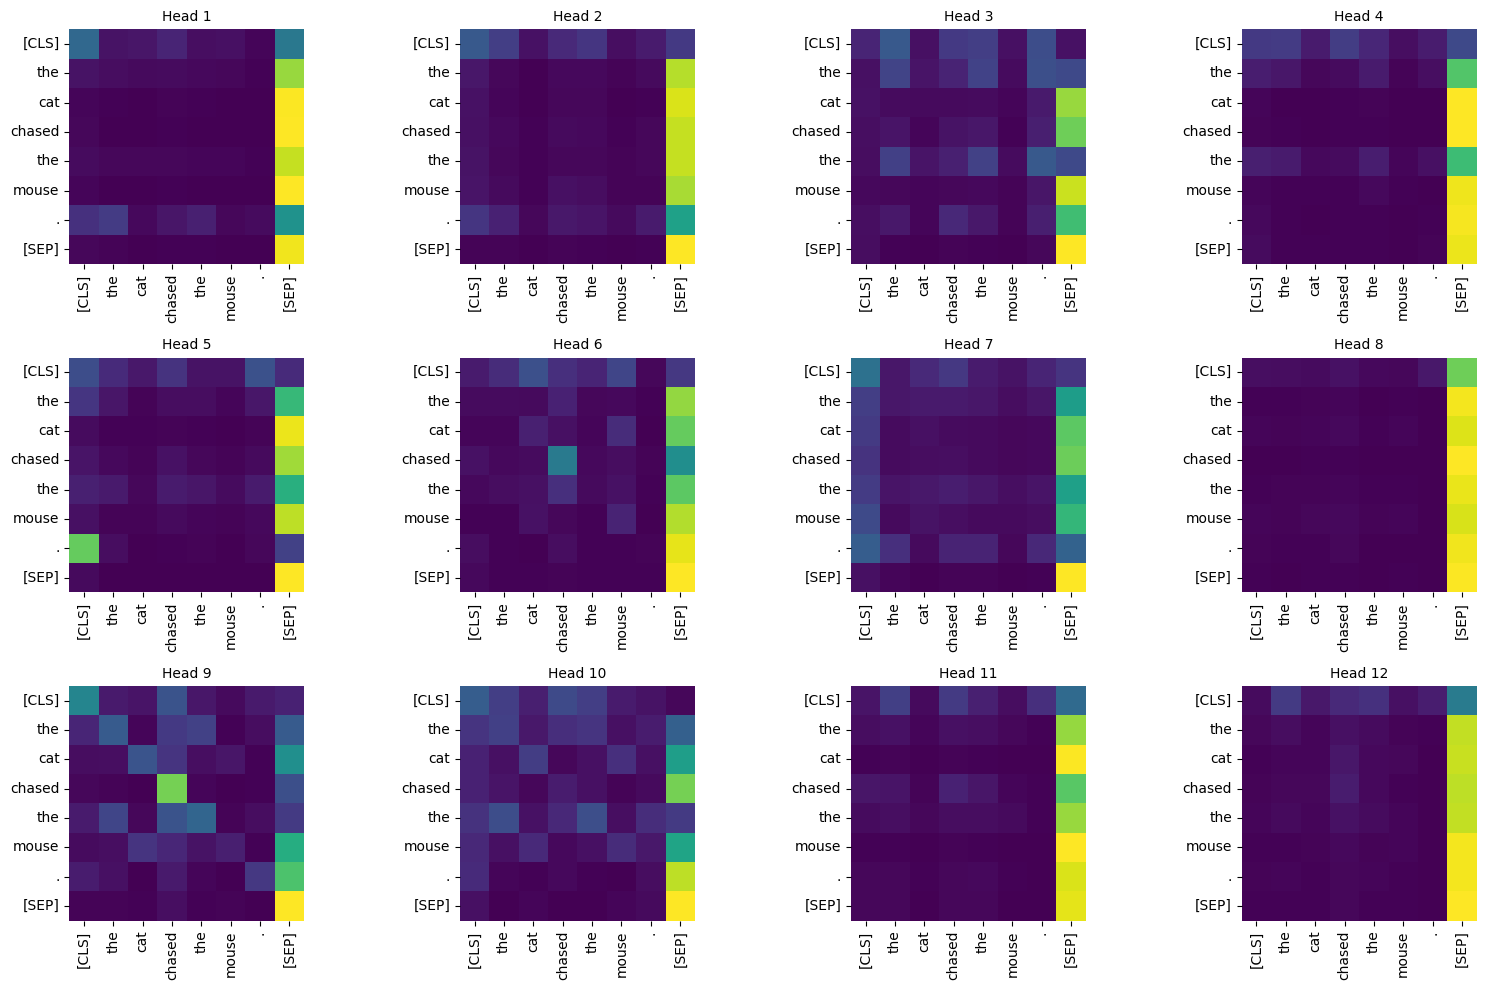

In [53]:
from transformers import BertTokenizer, BertModel
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Load model + tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)

sentence = "The cat chased the mouse."
inputs = tokenizer(sentence, return_tensors="pt")
outputs = model(**inputs)

# Attention from the last layer
attn = outputs.attentions[-1]   # (batch, heads, seq_len, seq_len)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
num_heads = attn.shape[1]

plt.figure(figsize=(16, 10))

for h in range(num_heads):
    plt.subplot(3, 4, h + 1)  # 3 rows × 4 columns for BERT-base’s 12 heads
    sns.heatmap(
        attn[0, h].detach().numpy(),
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="viridis",
        square=True,
        cbar=False
    )
    plt.title(f"Head {h+1}", fontsize=10)

plt.tight_layout()
plt.show()